In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
import os
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

from config import config
from utils import logger
from utils import show_batch

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# torch.cuda.empty_cache()

# Check Data Module

In [18]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')

INFO     | _get_names | Processing train
INFO     | _get_names | Processing normal
INFO     | _get_names | Image Pair Counts : MGO01_low_light cam0 : 535
INFO     | _get_names | Image Pair Counts : MGO01_low_light cam1 : 562
INFO     | _get_names | Image Pair Counts : MOO06_inspect_hard cam0 : 556
INFO     | _get_names | Image Pair Counts : MOO06_inspect_hard cam1 : 555
INFO     | _get_names | Image Pair Counts : MOO01_hand_puncher_1 cam0 : 609


INFO     | _get_names | Image Pair Counts : MOO01_hand_puncher_1 cam1 : 609
INFO     | _get_names | Image Pair Counts : MGO06_inspect_hard cam0 : 639
INFO     | _get_names | Image Pair Counts : MGO06_inspect_hard cam1 : 640
INFO     | _get_names | Image Pair Counts : MOO14_flickering_light cam0 : 714
INFO     | _get_names | Image Pair Counts : MOO14_flickering_light cam1 : 708
INFO     | _get_names | Image Pair Counts : MGO04_hand_shooter_hard cam0 : 741
INFO     | _get_names | Image Pair Counts : MGO04_hand_shooter_hard cam1 : 733
INFO     | _get_names | Image Pair Counts : MGO13_sudden_movements cam0 : 746
INFO     | _get_names | Image Pair Counts : MGO13_sudden_movements cam1 : 745
INFO     | _get_names | Image Pair Counts : MOO04_hand_shooter_hard cam0 : 785
INFO     | _get_names | Image Pair Counts : MOO04_hand_shooter_hard cam1 : 778
INFO     | _get_names | Image Pair Counts : MGO02_hand_puncher cam0 : 823
INFO     | _get_names | Image Pair Counts : MGO02_hand_puncher cam1 : 801


In [19]:
dl = dm.train_dataloader()

In [20]:
batch = next(iter(dl))

reference_patches = batch.reference_patches
target_patches = batch.target_patches
print(reference_patches.shape, target_patches.shape) 

patch_level_reference_coords = batch.patch_level_reference_coords
patch_level_target_coords = batch.patch_level_target_coords
print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

# rotations = batch.rotations
# print(rotations.shape)

torch.Size([53, 3, 32, 32]) torch.Size([53, 3, 32, 32])
torch.Size([53, 2]) torch.Size([53, 2])


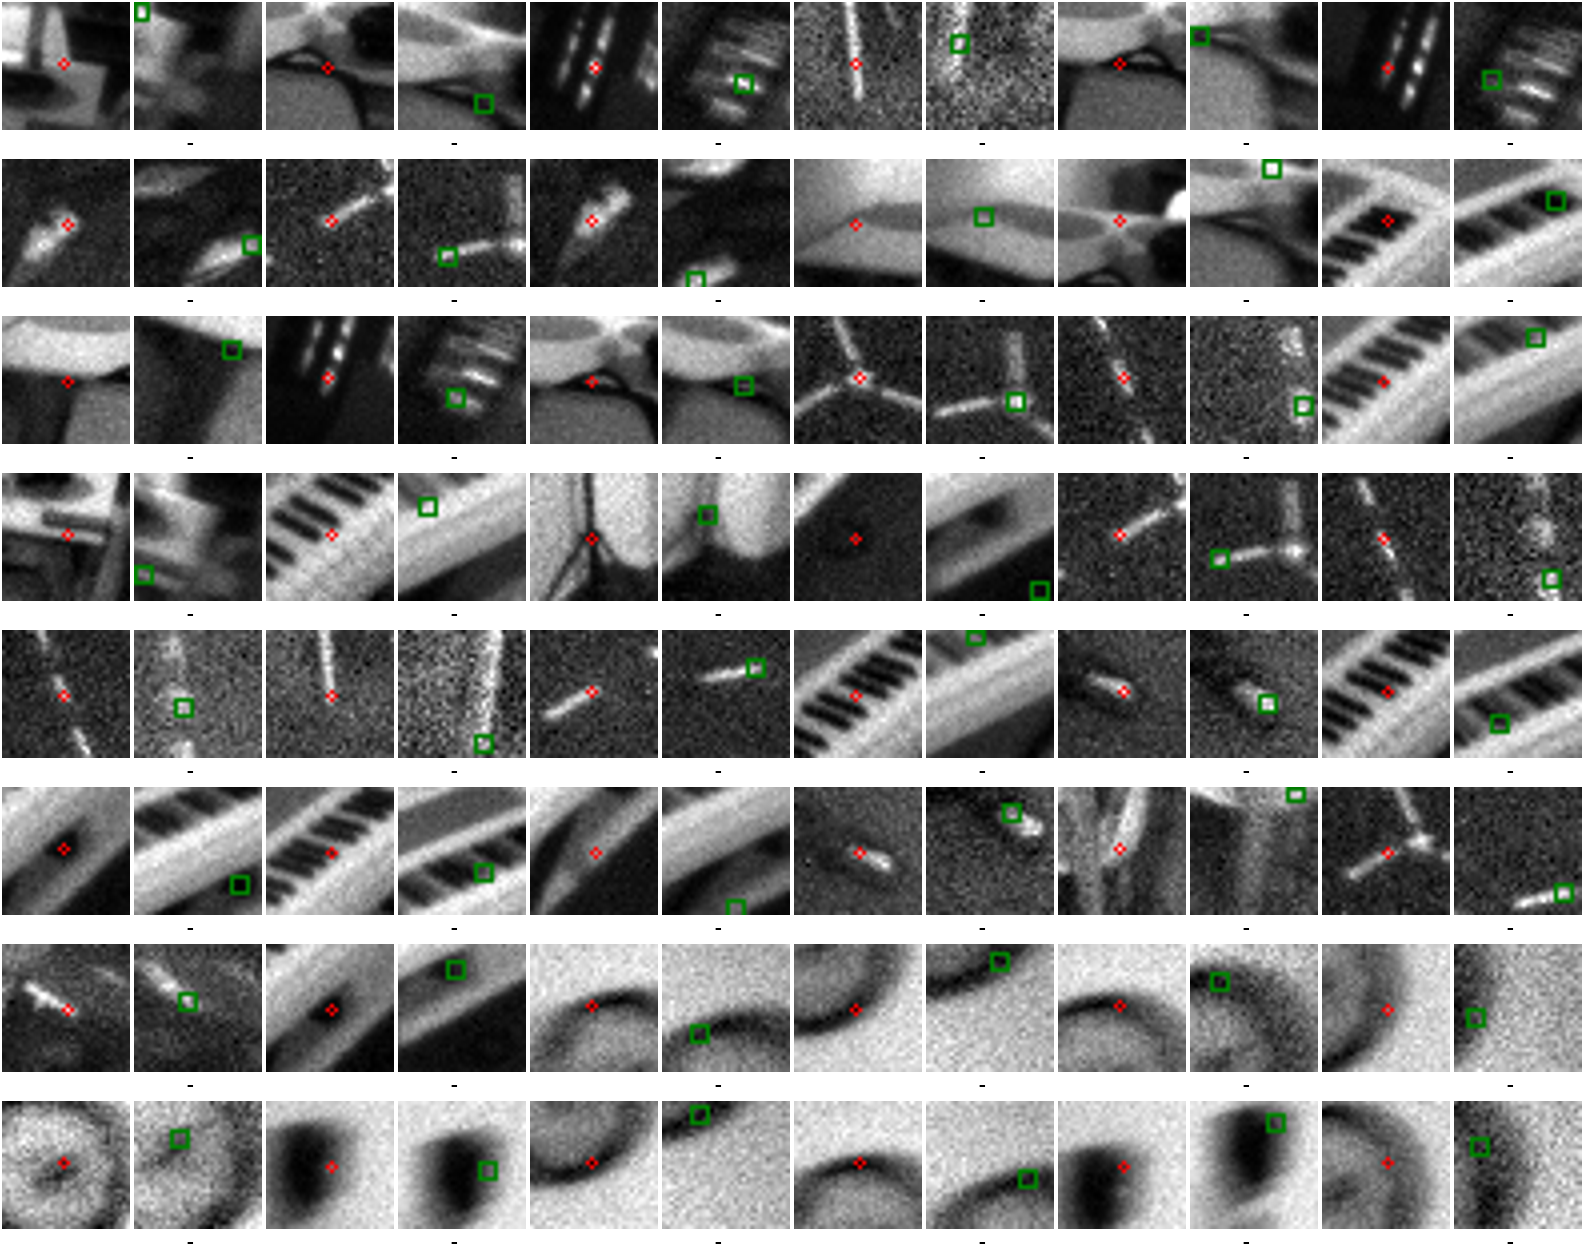

In [21]:
count = 24 * 2

# radians to degrees
# print(batch.rotations[:count] * (180 / torch.pi))
# print(batch.rotations[:count])

show_batch(
    reference_patches, target_patches,
    patch_level_reference_coords, patch_level_target_coords,
    patch_level_target_coords,
    # rotations_true=batch.rotations,
    # rotations=None,
    limit_count=count, 
    n_columns=6,
    just_gt=True
)

In [22]:
# for index, batch in enumerate(dl):
#     print(f'-- Batch Index {index} -----')
#     reference_patches = batch.reference_patches
#     target_patches = batch.target_patches
#     print(reference_patches.shape, target_patches.shape) 

#     patch_level_reference_coords = batch.patch_level_reference_coords
#     patch_level_target_coords = batch.patch_level_target_coords
#     print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

#     rotations = batch.rotations
#     print(rotations.shape)

# Check Model

In [23]:
from src import Light
light = Light()

In [24]:
from utils import count_params
count_params(light.model)

445123

In [25]:
print('Model Inputs')
print(f'reference_patches shape : {reference_patches.shape}')
print(f'target_patches shape : {target_patches.shape}')
print(f'patch_level_reference_coords shape : {patch_level_reference_coords.shape}')

reference_patches, target_patches, patch_level_reference_coords = reference_patches.to('cuda'), target_patches.to('cuda'), patch_level_reference_coords.to('cuda')

print('Model Outputs')

target_coords, target_confidence = light(
    reference_patches, 
    target_patches, 
    patch_level_reference_coords
)

print(f'target_coords shape : {target_coords.shape}')
# print(f'target_rotation shape : {target_rotation.shape}')
print(f'target_confidence shape : {target_confidence.shape}')

Model Inputs
reference_patches shape : torch.Size([53, 3, 32, 32])
target_patches shape : torch.Size([53, 3, 32, 32])
patch_level_reference_coords shape : torch.Size([53, 2])
Model Outputs
target_coords shape : torch.Size([53, 2])
target_confidence shape : torch.Size([53, 1])


# Confidence

In [26]:
# patch_level_reference_coords[:1], target_coords[:1]

In [27]:
# std_dev = 6.0
# covariance_matrix = torch.diag(torch.tensor([std_dev ** 2, std_dev ** 2], device=patch_level_reference_coords.device))

# gaussian = torch.distributions.MultivariateNormal(
#     loc=patch_level_reference_coords, 
#     covariance_matrix=covariance_matrix
# )

In [28]:
# # X = (target_coords + 1) * 15.5

# # X = patch_level_reference_coords + 10  # for testing std dev

# d = torch.arange(patch_level_reference_coords.shape[0], device=patch_level_reference_coords.device).unsqueeze(1)
# X = patch_level_reference_coords + d  # for testing std dev

# raw_probabilities = torch.exp(gaussian.log_prob(X))

In [29]:
# # Y = patch_level_reference_coords / 31.0
# # max_probabilities = torch.exp(gaussian.log_prob(Y))
# max_probabilities = torch.exp(gaussian.log_prob(patch_level_reference_coords))

# # Normalize probabilities to make p = 1 when coords_pred = coords
# normalized_probabilities = raw_probabilities / (max_probabilities + 0.000001)

In [30]:
# normalized_probabilities[:15]